In [759]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# fs = 100
# dt = 1 / fs


In [760]:
df_cuat = pd.read_csv(r"18-05_prueba_oficina\bad_parker\quaternionfilter_5.csv")

df_imu = pd.read_csv(r"18-05_prueba_oficina\bad_parker\sensordata_5.csv")

zupt_periods_hhmmss = [
    ("16:19:20.26", "16:19:38.00"),
    ("16:20:15.00", "16:20:35.00"),
    ("16:21:05.00", "16:21:33.67"),
]

In [761]:
df_cuat

,unix_time_ms,fGPS_ts_week,fGPS_ts_tow,fGPS_valid,estQ0,estQ1,estQ2,estQ3,estQ_valid,flag_sensor,flag_filter
0,1.779140e+12,2419,163800.11,3,0.999785,-0.014914,0.014414,-0.000736,1,0,0
1,1.779140e+12,2419,163800.12,3,0.999784,-0.014923,0.014413,-0.000729,1,0,0
2,1.779140e+12,2419,163800.14,3,0.999784,-0.014929,0.014418,-0.000716,1,0,0
3,1.779140e+12,2419,163800.15,3,0.999784,-0.014931,0.014417,-0.000710,1,0,0
4,1.779140e+12,2419,163800.17,3,0.999784,-0.014930,0.014412,-0.000707,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
7532,1.779140e+12,2419,163908.29,3,0.999810,-0.015181,0.012095,0.001805,1,0,0
7533,1.779140e+12,2419,163908.30,3,0.999810,-0.015174,0.012096,0.001785,1,0,0
7534,1.779140e+12,2419,163908.32,3,0.999810,-0.015159,0.012100,0.001751,1,0,0
7535,1.779140e+12,2419,163908.33,3,0.999810,-0.015156,0.012099,0.001745,1,0,0


In [762]:
# Renombrar columnas
cuat_new_names = ["q0", "q1", "q2", "q3", "zupt_flag"]
df_cuat = df_cuat.rename(columns=dict(zip(df_cuat.columns[4:8], cuat_new_names[:4])))

# df_cuat = df_cuat.rename(columns=dict(zip(df_cuat.columns[-1], cuat_new_names[-1])))
df_cuat = df_cuat.rename(columns={df_cuat.columns[-2]: cuat_new_names[-1]})

df_cuat = df_cuat.sort_values("fGPS_ts_tow").reset_index(drop=True)

df_cuat["Time"] = pd.to_numeric(df_cuat["unix_time_ms"]).round().astype("Int64")

df_cuat["timestamp"] = pd.to_datetime(df_cuat["Time"], unit="ms")

# Tiempo relativo en segundos
df_cuat["t"] = (df_cuat["fGPS_ts_tow"] - df_cuat["fGPS_ts_tow"].iloc[0])

# Delta de tiempo entre muestra
df_cuat["dt"] = df_cuat["t"].diff()

df_cuat.rename(columns={"fGPS_ts_tow": "fGPS_ts"}, inplace=True)

# Reordenar columnas
df_cuat = df_cuat.reindex(columns=['Time', 'fGPS_ts', 'timestamp', 't', 'dt', 'q0', 'q1', 'q2', 'q3' ,'zupt_flag'])

print(df_cuat["Time"].iloc[0])

df_cuat

1779139782110


,Time,fGPS_ts,timestamp,t,dt,q0,q1,q2,q3,zupt_flag
0,1779139782110,163800.11,2026-05-18 21:29:42.110,0.00,NaN,0.999785,-0.014914,0.014414,-0.000736,0
1,1779139782120,163800.12,2026-05-18 21:29:42.120,0.01,0.01,0.999784,-0.014923,0.014413,-0.000729,0
2,1779139782140,163800.14,2026-05-18 21:29:42.140,0.03,0.02,0.999784,-0.014929,0.014418,-0.000716,0
3,1779139782150,163800.15,2026-05-18 21:29:42.150,0.04,0.01,0.999784,-0.014931,0.014417,-0.000710,0
4,1779139782170,163800.17,2026-05-18 21:29:42.170,0.06,0.02,0.999784,-0.014930,0.014412,-0.000707,0
...,...,...,...,...,...,...,...,...,...,...
7532,1779139890290,163908.29,2026-05-18 21:31:30.290,108.18,0.02,0.999810,-0.015181,0.012095,0.001805,0
7533,1779139890300,163908.30,2026-05-18 21:31:30.300,108.19,0.01,0.999810,-0.015174,0.012096,0.001785,0
7534,1779139890320,163908.32,2026-05-18 21:31:30.320,108.21,0.02,0.999810,-0.015159,0.012100,0.001751,0
7535,1779139890330,163908.33,2026-05-18 21:31:30.330,108.22,0.01,0.999810,-0.015156,0.012099,0.001745,0


In [763]:
list(df_imu.columns.values)

['unix_time_ms_sensor',
 'GPS_ts_week',
 'GPS_ts_tow',
 'scaledAccelX',
 'scaledAccelY',
 'scaledAccelZ',
 'deltaVelX',
 'deltaVelY',
 'deltaVelZ',
 'unix_time_ms_filter',
 'fGPS_ts_week',
 'fGPS_ts_tow',
 'estLinAccelX',
 'estLinAccelY',
 'estLinAccelZ',
 'estLinAccel_valid',
 'estAngRateX',
 'estAngRateY',
 'estAngRateZ',
 'estAngRate_valid',
 'estGravityX',
 'estGravityY',
 'estGravityZ',
 'estGravity_valid',
 'flag_sensor',
 'flag_filter']

In [764]:
al_new_names = ["alx", "aly", "alz"]

df_imu = df_imu.rename(columns=dict(zip(df_imu.columns[12:16], al_new_names)))

df_imu["Time"] = pd.to_numeric(df_imu["unix_time_ms_sensor"]).round().astype("Int64")

df_imu.rename(columns={"GPS_ts_tow": "fGPS_ts"}, inplace=True)

df_imu = df_imu.reindex(columns=["Time", "fGPS_ts", "alx", "aly", "alz"])
# df_imu = df_imu.sort_values("fGPS_ts").reset_index(drop=True)

df_imu

,Time,fGPS_ts,alx,aly,alz
0,1779139782110,163800.11,0.008362,-0.014074,0.006066
1,1779139782120,163800.12,0.012507,-0.015494,-0.000503
2,1779139782140,163800.14,0.003490,0.015426,-0.001013
3,1779139782150,163800.15,0.003799,0.019985,-0.009311
4,1779139782170,163800.17,-0.004124,0.046717,-0.006868
...,...,...,...,...,...
7532,1779139890290,163908.29,0.001697,0.011183,0.006930
7533,1779139890300,163908.30,0.011486,-0.016127,-0.003844
7534,1779139890320,163908.32,0.017959,-0.073992,-0.004736
7535,1779139890330,163908.33,0.028016,-0.079392,-0.012890


In [765]:
tol_s = 0.005  # 5 ms

df_u = pd.merge_asof(
    df_cuat,
    df_imu,
    on="fGPS_ts",
    direction="nearest",
    tolerance=tol_s
)

# Eliminar filas donde no hubo coincidencia dentro de la tolerancia
df_u = df_u.dropna(
    subset=["alx", "aly", "alz"]
).reset_index(drop=True)

df_u

,Time_x,fGPS_ts,timestamp,t,dt,q0,q1,q2,q3,zupt_flag,Time_y,alx,aly,alz
0,1779139782110,163800.11,2026-05-18 21:29:42.110,0.00,NaN,0.999785,-0.014914,0.014414,-0.000736,0,1779139782110,0.008362,-0.014074,0.006066
1,1779139782120,163800.12,2026-05-18 21:29:42.120,0.01,0.01,0.999784,-0.014923,0.014413,-0.000729,0,1779139782120,0.012507,-0.015494,-0.000503
2,1779139782140,163800.14,2026-05-18 21:29:42.140,0.03,0.02,0.999784,-0.014929,0.014418,-0.000716,0,1779139782140,0.003490,0.015426,-0.001013
3,1779139782150,163800.15,2026-05-18 21:29:42.150,0.04,0.01,0.999784,-0.014931,0.014417,-0.000710,0,1779139782150,0.003799,0.019985,-0.009311
4,1779139782170,163800.17,2026-05-18 21:29:42.170,0.06,0.02,0.999784,-0.014930,0.014412,-0.000707,0,1779139782170,-0.004124,0.046717,-0.006868
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7532,1779139890290,163908.29,2026-05-18 21:31:30.290,108.18,0.02,0.999810,-0.015181,0.012095,0.001805,0,1779139890290,0.001697,0.011183,0.006930
7533,1779139890300,163908.30,2026-05-18 21:31:30.300,108.19,0.01,0.999810,-0.015174,0.012096,0.001785,0,1779139890300,0.011486,-0.016127,-0.003844
7534,1779139890320,163908.32,2026-05-18 21:31:30.320,108.21,0.02,0.999810,-0.015159,0.012100,0.001751,0,1779139890320,0.017959,-0.073992,-0.004736
7535,1779139890330,163908.33,2026-05-18 21:31:30.330,108.22,0.01,0.999810,-0.015156,0.012099,0.001745,0,1779139890330,0.028016,-0.079392,-0.012890


In [766]:
# Validación

print(df_u["dt"].describe())

fs_mean = 1 / df_u["dt"].iloc[1:].mean()
print(f"Frecuencia promedio: {fs_mean:.2f} Hz")

count    7536.000000
mean        0.014362
std         0.004999
min         0.010000
25%         0.010000
50%         0.010000
75%         0.020000
max         0.030000
Name: dt, dtype: float64
Frecuencia promedio: 69.63 Hz


In [767]:
import numpy as np
import pandas as pd
from scipy.spatial.transform import Rotation as R


def ins_strapdown_dead_reckoning(
    df,
    acc_cols=("alx", "aly", "alz"),
    quat_cols=("q0", "q1", "q2", "q3"),
    time_col="t",
    dt_col="dt",

    # Columna ZUPT desde la tabla
    zupt_flag_col="zupt_flag",

    # Ganancias generales
    G_acc=1.0,
    p_gain=1.0,

    # ZUPT por flag
    ZUPT_GAIN=1.0,
    hard_zupt=True,

    # Non-Holonomic Constraints
    use_nhc=True,
    K_nhc_y=0.9,
    K_nhc_z=0.9,

    # Convención de rotación
    use_transpose=True,

    # Opciones
    normalize_quat=True,
    verbose=True
):
    """
    INS strapdown básico para Dead Reckoning usando:
        - aceleración lineal en body
        - cuaternión de orientación
        - ZUPT activado por columna zupt_flag
        - NHC para vehículo terrestre

    La columna zupt_flag debe contener:
        0 -> no aplicar ZUPT
        1 -> aplicar ZUPT
    """

    df_out = df.copy()

    # -----------------------------
    # Validaciones mínimas
    # -----------------------------
    required_cols = list(acc_cols) + list(quat_cols) + [time_col, dt_col, zupt_flag_col]
    missing = [c for c in required_cols if c not in df_out.columns]

    if missing:
        raise ValueError(f"Faltan columnas en el DataFrame: {missing}")

    # Convertir a numérico
    for c in required_cols:
        df_out[c] = pd.to_numeric(df_out[c], errors="coerce")

    # Por seguridad, la flag se fuerza a 0/1
    df_out[zupt_flag_col] = df_out[zupt_flag_col].fillna(0).astype(int)

    # Inicialización
    p = np.zeros(3, dtype=float)
    v = np.zeros(3, dtype=float)

    # Crear columnas de salida
    output_cols = [
        "a_nav_x", "a_nav_y", "a_nav_z",
        "a_body_x_nhc", "a_body_y_nhc", "a_body_z_nhc",
        "a_nav_x_nhc", "a_nav_y_nhc", "a_nav_z_nhc",
        "v_int_x", "v_int_y", "v_int_z",
        "vx_body_raw", "vy_body_raw", "vz_body_raw",
        "vx_body_nhc", "vy_body_nhc", "vz_body_nhc",
        "vx", "vy", "vz",
        "px", "py", "pz",
        "px_scale", "py_scale", "pz_scale",
        "zupt_applied"
    ]

    for col in output_cols:
        df_out[col] = np.nan

    a_nav_prev = None

    # -----------------------------
    # Loop strapdown
    # -----------------------------
    for k in range(len(df_out)):

        t = df_out.loc[k, time_col]
        dt = df_out.loc[k, dt_col]

        # Leer flag ZUPT desde la tabla
        zupt_flag = int(df_out.loc[k, zupt_flag_col])

        # Para la primera fila normalmente dt es NaN
        if pd.isna(t) or pd.isna(dt) or dt <= 0:
            df_out.loc[k, ["vx", "vy", "vz"]] = v
            df_out.loc[k, ["px", "py", "pz"]] = p
            df_out.loc[k, ["px_scale", "py_scale", "pz_scale"]] = p_gain * p
            df_out.loc[k, "zupt_applied"] = zupt_flag
            continue

        # -----------------------------
        # 1. Leer aceleración en body
        # -----------------------------
        a_body = df_out.loc[k, list(acc_cols)].to_numpy(dtype=float)

        if np.any(np.isnan(a_body)):
            df_out.loc[k, ["vx", "vy", "vz"]] = v
            df_out.loc[k, ["px", "py", "pz"]] = p
            df_out.loc[k, ["px_scale", "py_scale", "pz_scale"]] = p_gain * p
            df_out.loc[k, "zupt_applied"] = zupt_flag
            continue

        # -----------------------------
        # 2. Leer y normalizar cuaternión
        # -----------------------------
        q = df_out.loc[k, list(quat_cols)].to_numpy(dtype=float)

        if np.any(np.isnan(q)):
            df_out.loc[k, ["vx", "vy", "vz"]] = v
            df_out.loc[k, ["px", "py", "pz"]] = p
            df_out.loc[k, ["px_scale", "py_scale", "pz_scale"]] = p_gain * p
            df_out.loc[k, "zupt_applied"] = zupt_flag
            continue

        q_norm = np.linalg.norm(q)

        if q_norm <= 0:
            df_out.loc[k, ["vx", "vy", "vz"]] = v
            df_out.loc[k, ["px", "py", "pz"]] = p
            df_out.loc[k, ["px_scale", "py_scale", "pz_scale"]] = p_gain * p
            df_out.loc[k, "zupt_applied"] = zupt_flag
            continue

        if normalize_quat:
            q = q / q_norm

        q0, q1, q2, q3 = q

        # scipy usa formato [x, y, z, w]
        r = R.from_quat([q1, q2, q3, q0])

        if use_transpose:
            R_nb = r.as_matrix().T
        else:
            R_nb = r.as_matrix()

        # -----------------------------
        # 3. Aceleración body -> navegación
        # -----------------------------
        a_nav = G_acc * (R_nb @ a_body)

        df_out.loc[k, ["a_nav_x", "a_nav_y", "a_nav_z"]] = a_nav

        # -----------------------------
        # 4. Integración trapezoidal de velocidad libre
        # -----------------------------
        v_prev = v.copy()

        if a_nav_prev is None:
            a_nav_prev = a_nav.copy()

        v = v + 0.5 * (a_nav_prev + a_nav) * dt

        df_out.loc[k, ["v_int_x", "v_int_y", "v_int_z"]] = v

        # -----------------------------
        # 5. ZUPT usando flag de la tabla
        # -----------------------------
        df_out.loc[k, "zupt_applied"] = zupt_flag

        if zupt_flag == 0:
            if hard_zupt:
                v[:] = 0.0
            else:
                v = v - ZUPT_GAIN * v

        # -----------------------------
        # 6. NHC: velocidad nav -> body
        # -----------------------------
        a_nav_nhc = a_nav.copy()

        if use_nhc:
            v_body = R_nb.T @ v

            df_out.loc[k, ["vx_body_raw", "vy_body_raw", "vz_body_raw"]] = v_body

            # Forma recomendable usando tus ganancias
            # x: avance longitudinal
            # y: velocidad lateral
            # z: velocidad vertical
            v_body[1] = v_body[1] * (1.0 - K_nhc_y)
            v_body[2] = v_body[2] * (1.0 - K_nhc_z)

            df_out.loc[k, ["vx_body_nhc", "vy_body_nhc", "vz_body_nhc"]] = v_body

            # Volver velocidad a navegación
            v = R_nb @ v_body

            # Opcional: aceleración también restringida en body
            a_body_nhc = a_body.copy()
            a_body_nhc[1] = a_body_nhc[1] * (1.0 - K_nhc_y)
            a_body_nhc[2] = a_body_nhc[2] * (1.0 - K_nhc_z)

            df_out.loc[k, ["a_body_x_nhc", "a_body_y_nhc", "a_body_z_nhc"]] = a_body_nhc

            a_nav_nhc = R_nb @ a_body_nhc

            df_out.loc[k, ["a_nav_x_nhc", "a_nav_y_nhc", "a_nav_z_nhc"]] = a_nav_nhc

        # -----------------------------
        # 7. Integración trapezoidal de posición
        # -----------------------------
        p = p + 0.5 * (v_prev + v) * dt
        a_nav_prev = a_nav.copy()

        p_scale = p_gain * p

        df_out.loc[k, ["vx", "vy", "vz"]] = v
        df_out.loc[k, ["px", "py", "pz"]] = p
        df_out.loc[k, ["px_scale", "py_scale", "pz_scale"]] = p_scale

    if verbose:
        print("INS strapdown finalizado.")
        print(f"Filas procesadas: {len(df_out)}")
        print(f"Posición final [m]: {p}")
        print(f"Velocidad final [m/s]: {v}")
        print(f"Muestras con ZUPT aplicado: {df_out['zupt_applied'].sum()}")

    return df_out

In [768]:
import pandas as pd
import numpy as np


def hhmmss_to_seconds(hhmmss):
    """
    Convierte una hora tipo:
        '16:46:25.77'
        '16:47:00.7'
        '16:47:27'
    a segundos desde las 00:00:00.
    """

    parts = hhmmss.strip().split(":")

    if len(parts) != 3:
        raise ValueError(f"Formato inválido: {hhmmss}. Usa HH:MM:SS.sss")

    h = int(parts[0])
    m = int(parts[1])
    s = float(parts[2])

    return h * 3600 + m * 60 + s


def convert_zupt_periods_hhmmss_to_relative(zupt_periods_hhmmss, start_time_hhmmss):
    """
    Convierte periodos ZUPT dados en hora real HH:MM:SS.sss
    a periodos relativos en segundos respecto a start_time_hhmmss.

    Ejemplo:
        start_time_hhmmss = '16:46:09.77'

        zupt_periods_hhmmss = [
            ('16:46:25.77', '16:46:30.25'),
            ('16:46:52.64', '16:47:00.7')
        ]

    Retorna:
        [
            (16.0, 20.48),
            (42.87, 50.93)
        ]
    """

    t0_abs = hhmmss_to_seconds(start_time_hhmmss)

    zupt_periods_rel = []

    for t_ini_str, t_fin_str in zupt_periods_hhmmss:
        t_ini_abs = hhmmss_to_seconds(t_ini_str)
        t_fin_abs = hhmmss_to_seconds(t_fin_str)

        t_ini_rel = t_ini_abs - t0_abs
        t_fin_rel = t_fin_abs - t0_abs

        if t_fin_rel < t_ini_rel:
            raise ValueError(
                f"Periodo inválido: {t_ini_str} - {t_fin_str}. "
                "El tiempo final es menor que el inicial."
            )

        zupt_periods_rel.append((t_ini_rel, t_fin_rel))

    return zupt_periods_rel

In [769]:
zupt_periods = convert_zupt_periods_hhmmss_to_relative(
    zupt_periods_hhmmss,
    start_time_hhmmss
)

print(zupt_periods)

[(0.0, 17.739999999997963), (54.73999999999796, 74.73999999999796), (104.73999999999796, 133.40999999999622)]


In [770]:
# # Periodos donde sabes que el vehículo está detenido

# zupt_periods = [
#     #  t_inicio, t_final
#     (0, 18),    # detenido al inicio
#     (55, 75),
#     (105, 133),  # detenido al final
# ]

In [771]:
df_ins = ins_strapdown_dead_reckoning(
    df=df_u,
    acc_cols=("alx", "aly", "alz"),
    quat_cols=("q0", "q1", "q2", "q3"),
    time_col="t",
    dt_col="dt",

    G_acc=1.0,
    p_gain=1.0,

    # zupt_periods=zupt_periods,
    ZUPT_GAIN=1.0,
    hard_zupt=True,

    use_nhc=True,
    K_nhc_y=0.9,
    K_nhc_z=0.9,

    use_transpose=True
)

df_ins.head()

INS strapdown finalizado.
Filas procesadas: 7537
Posición final [m]: [ 22.90817998 -22.76969575  -0.47327734]
Velocidad final [m/s]: [0. 0. 0.]
Muestras con ZUPT aplicado: 7254.0


,Time_x,fGPS_ts,timestamp,t,dt,q0,q1,q2,q3,zupt_flag,...,vx,vy,vz,px,py,pz,px_scale,py_scale,pz_scale,zupt_applied
0,1779139782110,163800.11,2026-05-18 21:29:42.110,0.00,NaN,0.999785,-0.014914,0.014414,-0.000736,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1779139782120,163800.12,2026-05-18 21:29:42.120,0.01,0.01,0.999784,-0.014923,0.014413,-0.000729,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1779139782140,163800.14,2026-05-18 21:29:42.140,0.03,0.02,0.999784,-0.014929,0.014418,-0.000716,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1779139782150,163800.15,2026-05-18 21:29:42.150,0.04,0.01,0.999784,-0.014931,0.014417,-0.000710,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1779139782170,163800.17,2026-05-18 21:29:42.170,0.06,0.02,0.999784,-0.014930,0.014412,-0.000707,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [772]:
df_ins.head

<bound method NDFrame.head of              Time_x    fGPS_ts               timestamp       t    dt  \
0     1779139782110  163800.11 2026-05-18 21:29:42.110    0.00   NaN   
1     1779139782120  163800.12 2026-05-18 21:29:42.120    0.01  0.01   
2     1779139782140  163800.14 2026-05-18 21:29:42.140    0.03  0.02   
3     1779139782150  163800.15 2026-05-18 21:29:42.150    0.04  0.01   
4     1779139782170  163800.17 2026-05-18 21:29:42.170    0.06  0.02   
...             ...        ...                     ...     ...   ...   
7532  1779139890290  163908.29 2026-05-18 21:31:30.290  108.18  0.02   
7533  1779139890300  163908.30 2026-05-18 21:31:30.300  108.19  0.01   
7534  1779139890320  163908.32 2026-05-18 21:31:30.320  108.21  0.02   
7535  1779139890330  163908.33 2026-05-18 21:31:30.330  108.22  0.01   
7536  1779139890340  163908.34 2026-05-18 21:31:30.340  108.23  0.01   

            q0        q1        q2        q3  zupt_flag  ...   vx   vy   vz  \
0     0.999785 -0.014914  

In [773]:
# v_cols=("vx_body_raw", "vy_body_raw", "vz_body_raw")

# v_body = df_ins.loc[2000, list(v_cols)].to_numpy(dtype=float)

# # df_u.loc[2000, ["vx_body_raw", "vy_body_raw", "vz_body_raw"]] = v_body

# print(v_body)
# print(v_body.shape)


# # Restricción no holonómica:
# # vehículo no debería desplazarse lateral ni verticalmente
# # v_body[1] = v_body[1] * (1.0 - K_nhc_y)
# # v_body[2] = v_body[2] * (1.0 - K_nhc_z)
# B = np.array([1, 0, 0])
# print(B)
# print(B.shape)
# v_body = v_body * B
# print(v_body)

In [774]:
df_ins.to_csv(r'14_05_26\csv_output\prueba_2.csv', index=False)
df_ins

,Time_x,fGPS_ts,timestamp,t,dt,q0,q1,q2,q3,zupt_flag,...,vx,vy,vz,px,py,pz,px_scale,py_scale,pz_scale,zupt_applied
0,1779139782110,163800.11,2026-05-18 21:29:42.110,0.00,NaN,0.999785,-0.014914,0.014414,-0.000736,0,...,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0
1,1779139782120,163800.12,2026-05-18 21:29:42.120,0.01,0.01,0.999784,-0.014923,0.014413,-0.000729,0,...,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0
2,1779139782140,163800.14,2026-05-18 21:29:42.140,0.03,0.02,0.999784,-0.014929,0.014418,-0.000716,0,...,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0
3,1779139782150,163800.15,2026-05-18 21:29:42.150,0.04,0.01,0.999784,-0.014931,0.014417,-0.000710,0,...,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0
4,1779139782170,163800.17,2026-05-18 21:29:42.170,0.06,0.02,0.999784,-0.014930,0.014412,-0.000707,0,...,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7532,1779139890290,163908.29,2026-05-18 21:31:30.290,108.18,0.02,0.999810,-0.015181,0.012095,0.001805,0,...,0.0,0.0,0.0,22.90818,-22.769696,-0.473277,22.90818,-22.769696,-0.473277,0.0
7533,1779139890300,163908.30,2026-05-18 21:31:30.300,108.19,0.01,0.999810,-0.015174,0.012096,0.001785,0,...,0.0,0.0,0.0,22.90818,-22.769696,-0.473277,22.90818,-22.769696,-0.473277,0.0
7534,1779139890320,163908.32,2026-05-18 21:31:30.320,108.21,0.02,0.999810,-0.015159,0.012100,0.001751,0,...,0.0,0.0,0.0,22.90818,-22.769696,-0.473277,22.90818,-22.769696,-0.473277,0.0
7535,1779139890330,163908.33,2026-05-18 21:31:30.330,108.22,0.01,0.999810,-0.015156,0.012099,0.001745,0,...,0.0,0.0,0.0,22.90818,-22.769696,-0.473277,22.90818,-22.769696,-0.473277,0.0


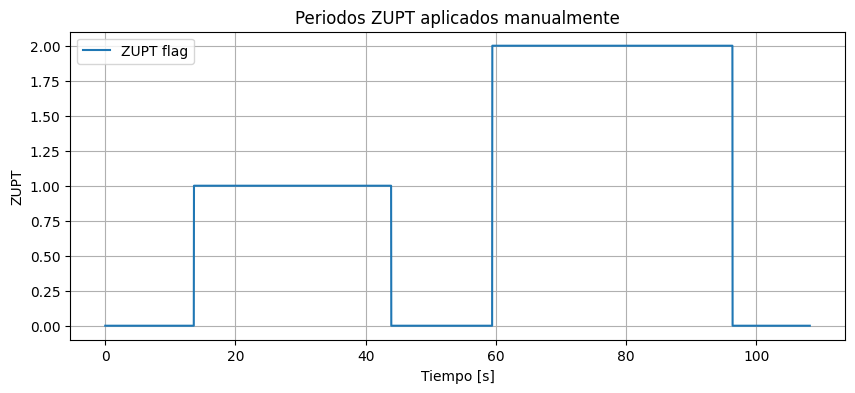

In [775]:
plt.figure(figsize=(10, 4))
plt.plot(df_ins["t"], df_ins["zupt_flag"], label="ZUPT flag")
plt.xlabel("Tiempo [s]")
plt.ylabel("ZUPT")
plt.title("Periodos ZUPT aplicados manualmente")
plt.grid(True)
plt.legend()
plt.show()

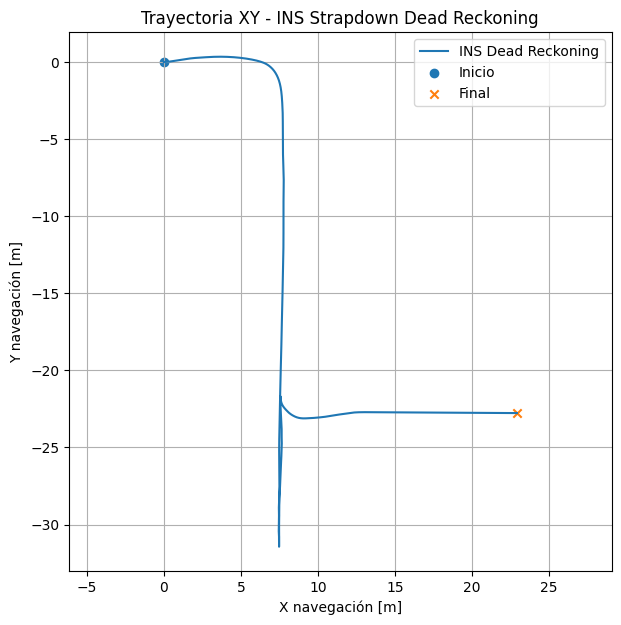

In [776]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.plot(df_ins["px"], df_ins["py"], label="INS Dead Reckoning")

plt.scatter(df_ins["px"].iloc[0], df_ins["py"].iloc[0], label="Inicio", marker="o")
plt.scatter(df_ins["px"].iloc[-1], df_ins["py"].iloc[-1], label="Final", marker="x")

plt.xlabel("X navegación [m]")
plt.ylabel("Y navegación [m]")
plt.title("Trayectoria XY - INS Strapdown Dead Reckoning")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

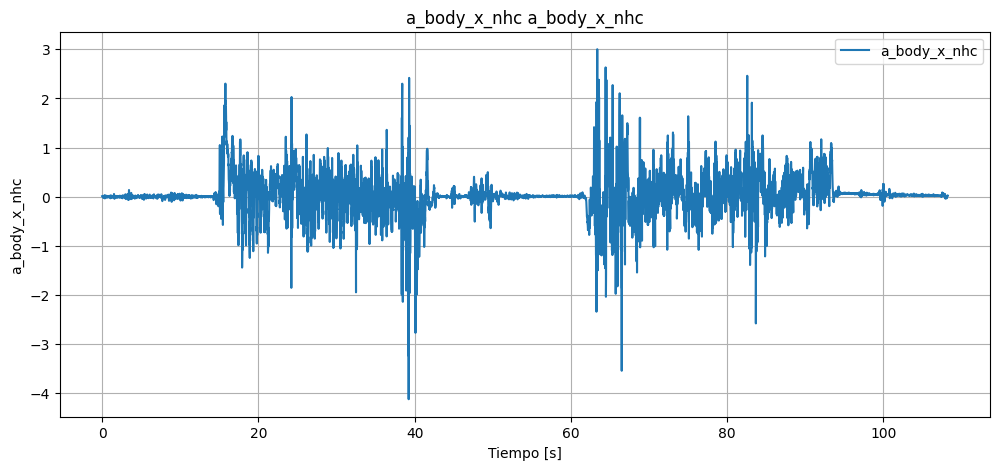

In [777]:
# for col in ["a_body_x_nhc", "a_body_y_nhc", "a_body_z_nhc"]:
col = "a_body_x_nhc"
plt.figure(figsize=(12, 5))
plt.plot(df_ins["t"], df_ins[col], label=col)
plt.xlabel("Tiempo [s]")
plt.ylabel("a_body_x_nhc")
plt.title(f"a_body_x_nhc {col}")
plt.legend()
plt.grid(True)
plt.show()

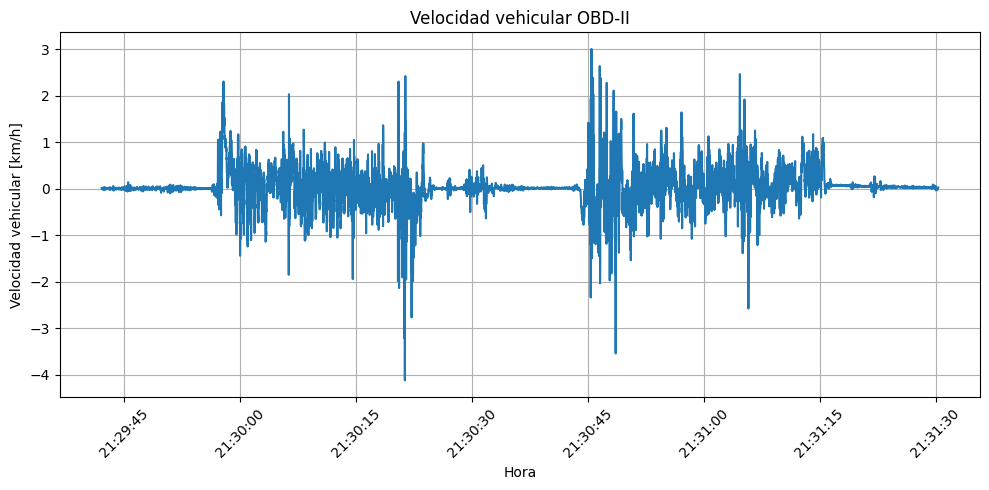

In [778]:
plt.figure(figsize=(10, 5))
plt.plot(df_ins["timestamp"], df_ins["a_body_x_nhc"])
plt.xlabel("Hora")
plt.ylabel("Velocidad vehicular [km/h]")
plt.title("Velocidad vehicular OBD-II")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

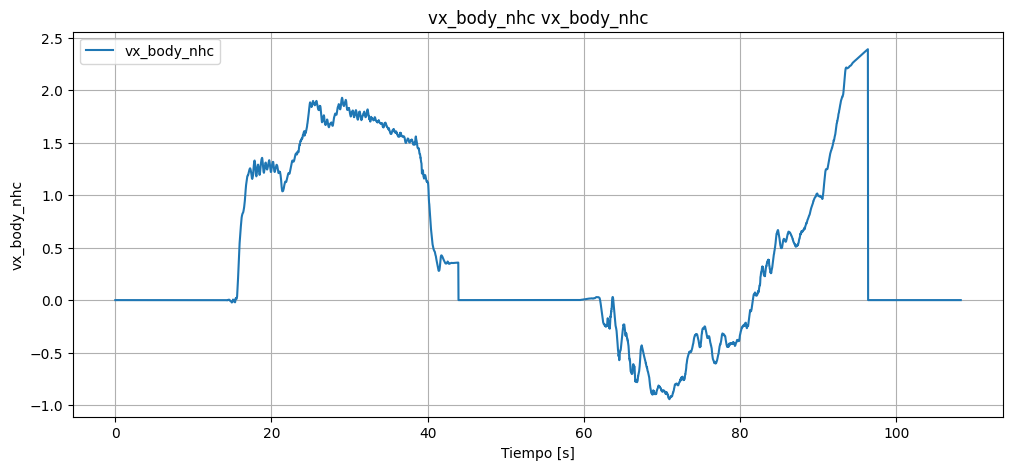

In [779]:
# for col in ["vx_body_nhc", "vy_body_nhc", "vz_body_nhc"]:
col = "vx_body_nhc"
plt.figure(figsize=(12, 5))
plt.plot(df_ins["t"], df_ins[col], label=col)
plt.xlabel("Tiempo [s]")
plt.ylabel("vx_body_nhc")
plt.title(f"vx_body_nhc {col}")
plt.legend()
plt.grid(True)
plt.show()


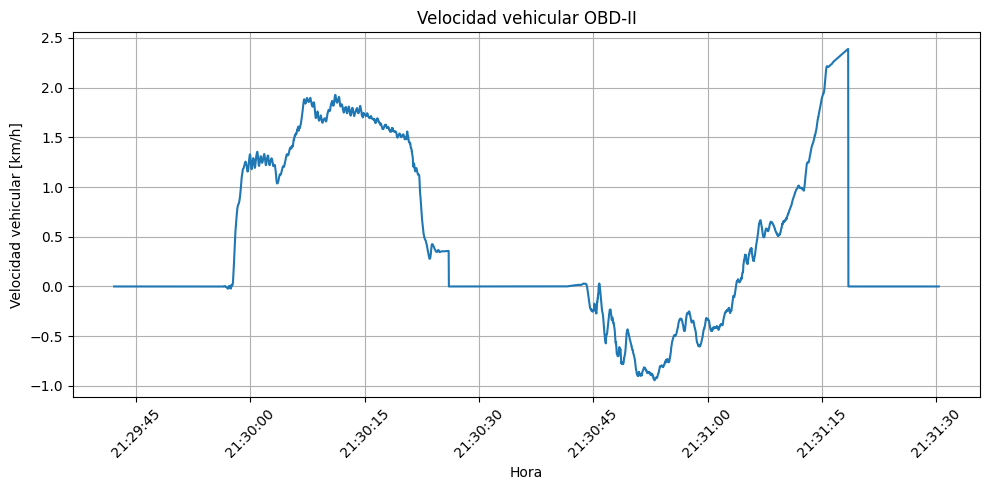

In [780]:
plt.figure(figsize=(10, 5))
plt.plot(df_ins["timestamp"], df_ins["vx_body_nhc"])
plt.xlabel("Hora")
plt.ylabel("Velocidad vehicular [km/h]")
plt.title("Velocidad vehicular OBD-II")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

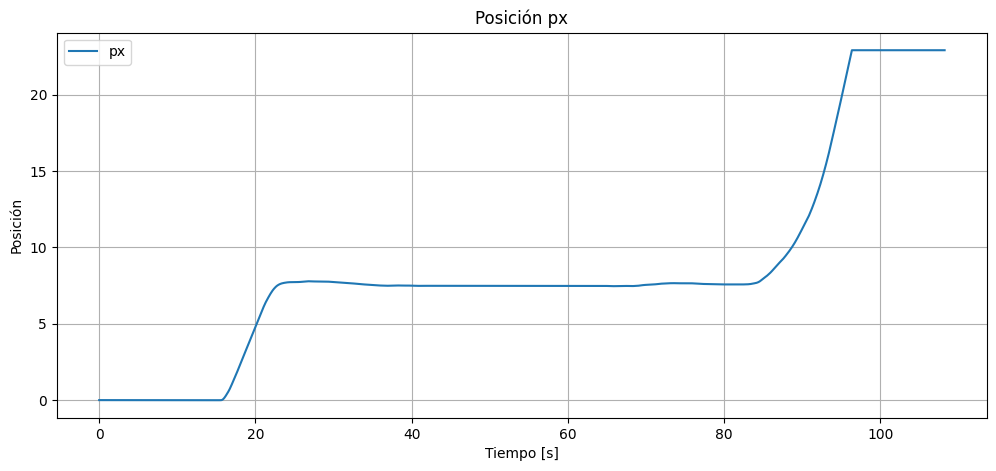

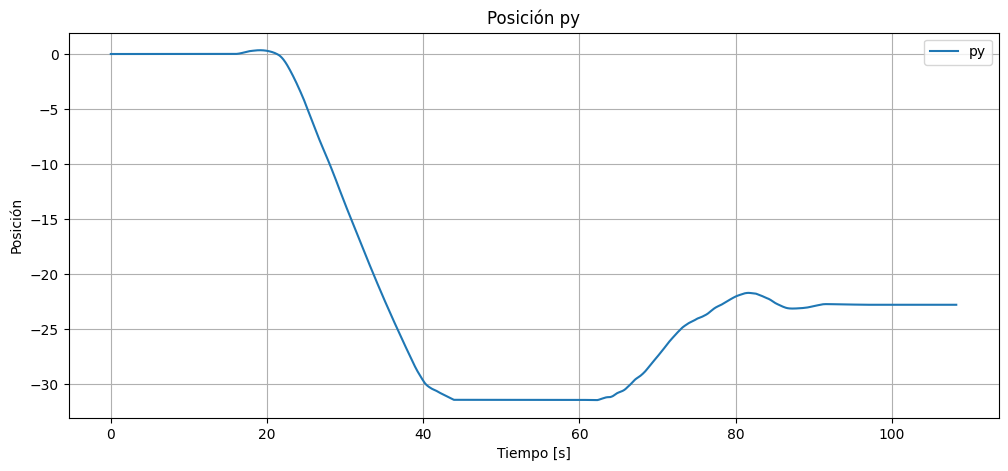

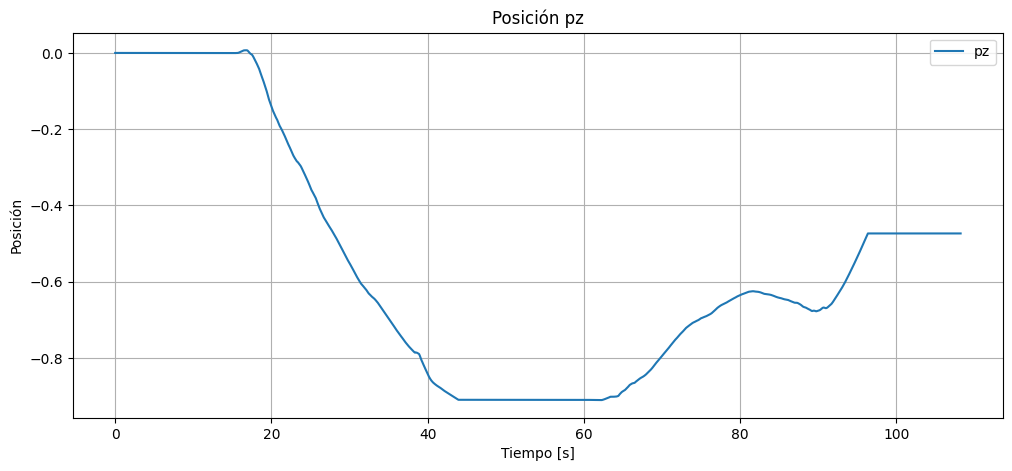

In [781]:
for col in ["px", "py", "pz"]:
    plt.figure(figsize=(12, 5))
    plt.plot(df_ins["t"], df_ins[col], label=col)
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Posición")
    plt.title(f"Posición {col}")
    plt.legend()
    plt.grid(True)
    plt.show()